In [35]:
#Importing  packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:

data = pd.read_csv('/content/seasonal_agriculture_performance_dataset .csv')
data.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [37]:
data.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [38]:
data.shape

(4000, 28)

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [40]:
#Statistical information
data.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [41]:
# missing values
data.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [42]:
#duplicate rows
data.duplicated().sum()

np.int64(0)

## Data Cleaning

A small number of missing values are present in Rainfall, Soil Moisture and Yield. Since Yield is an important performance measure, records with missing Yield are excluded from yield-based analysis. Missing Rainfall and Soil Moisture values are filled using their median values. No duplicate records are present.

In [43]:
#Handle missing values
data['Rainfall_mm'] = data['Rainfall_mm'].fillna(data['Rainfall_mm'].median())
data['Soil_Moisture_pct'] = data['Soil_Moisture_pct'].fillna(data['Soil_Moisture_pct'].median())
data = data.dropna(subset=['Yield_Tonnes_Ha']).copy()


In [44]:
data.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


## Questions:

### 1. How is crop performance different in each season?

In [45]:
data.groupby('Season')[[
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Revenue_INR',
    'Profit_INR'
]].mean()

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Season,,,,
Kharif,5.643973,46.440830,711441.277652,179367.124718
Rabi,5.080498,41.337953,601825.545737,88197.251400
Zaid,4.665942,39.146146,516662.120543,-26592.397284


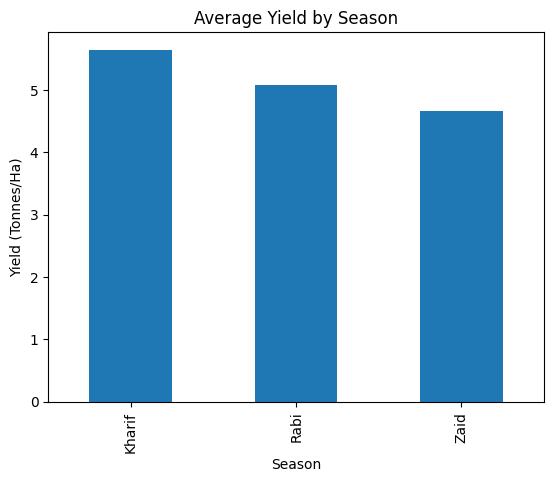

In [46]:
data.groupby('Season')['Yield_Tonnes_Ha'].mean().plot(kind='bar')
plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

### 2.2. How does production change across seasons?

In [47]:
data.groupby('Season')['Production_Tonnes'].mean()

,Production_Tonnes
Season,
Kharif,46.440830
Rabi,41.337953
Zaid,39.146146


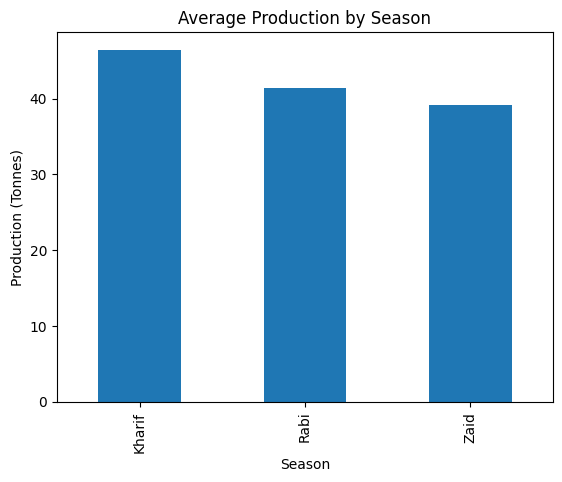

In [48]:
data.groupby('Season')['Production_Tonnes'].mean().plot(kind='bar')

plt.title('Average Production by Season')
plt.xlabel('Season')
plt.ylabel('Production (Tonnes)')
plt.show()

### 3. How do the environmental conditions change by season?

In [49]:
# Average environmental conditions by season
data.groupby('Season')[[
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct'
]].mean()

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct
Season,,,,,,
Kharif,848.690293,28.448251,71.843962,6.792212,6.728713,31.152032
Rabi,437.928625,23.496204,57.923149,7.594213,6.672813,24.094960
Zaid,304.251613,31.050594,51.988455,8.179796,6.692683,19.273514


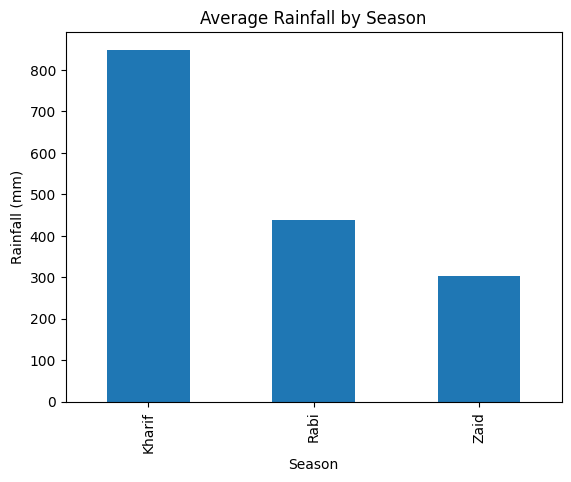

In [50]:
data.groupby('Season')['Rainfall_mm'].mean().plot(kind='bar')
plt.title('Average Rainfall by Season')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')
plt.show()

### 4. How do farming activities differ between seasons?

In [51]:
# Average farming inputs by season
data.groupby('Season')[[
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha'
]].mean()

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,,,
Kharif,119.959086,58.087302,105.316648,187.041027,5.078736
Rabi,120.307716,57.316801,103.814250,185.282016,5.025669
Zaid,120.651613,58.277080,105.356706,184.233447,5.162598


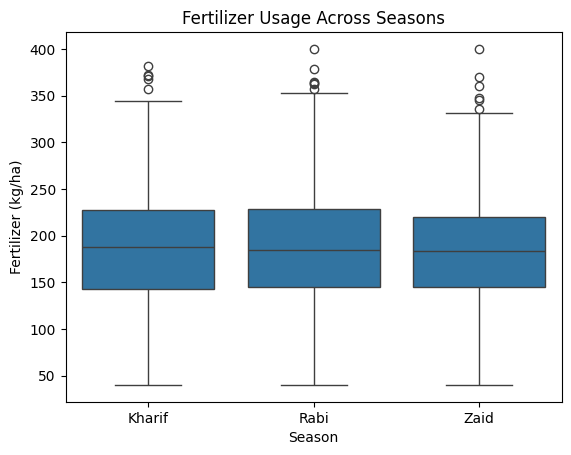

In [52]:
sns.boxplot(data=data, x='Season', y='Fertilizer_kg_ha')
plt.title('Fertilizer Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Fertilizer (kg/ha)')
plt.show()

### 5. How does resource usage change across seasons?

In [53]:
# Average resource usage by season
data.groupby('Season')[[
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3'
]].mean()

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.041027,5.078736,6094.046275,5.906584
Rabi,185.282016,5.025669,5837.238955,5.178462
Zaid,184.233447,5.162598,6423.076401,4.440922


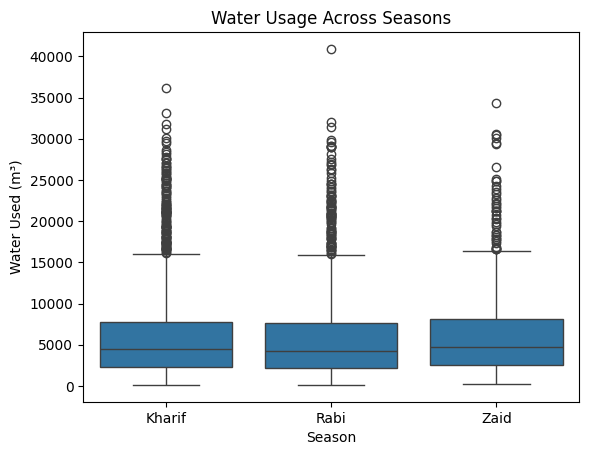

In [54]:
sns.boxplot(data=data, x='Season', y='Water_Used_m3')
plt.title('Water Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Water Used (m³)')
plt.show()

### 6. Do weather conditions have any relation with crop yield?

In [55]:
# Check the relation between environmental conditions and yield
data[[
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha'
]].corr()['Yield_Tonnes_Ha']

,Yield_Tonnes_Ha
Rainfall_mm,0.030545
Avg_Temperature_C,0.009349
Humidity_pct,0.011277
Sunlight_Hours_Day,-0.015362
Soil_pH,-0.020664
Soil_Moisture_pct,0.010119
Yield_Tonnes_Ha,1.000000


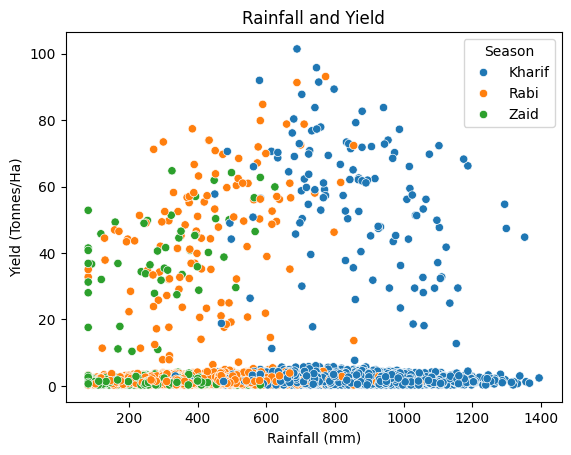

In [56]:
sns.scatterplot(data=data, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season')
plt.title('Rainfall and Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

### 7. Which season has better financial results?

In [57]:
# Average price, cost, revenue and profit by season
data.groupby('Season')[[
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR'
]].mean()

,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,
Kharif,44846.628104,532074.152935,711441.277652,179367.124718
Rabi,44770.594275,513628.294337,601825.545737,88197.251400
Zaid,43957.755518,543254.517827,516662.120543,-26592.397284


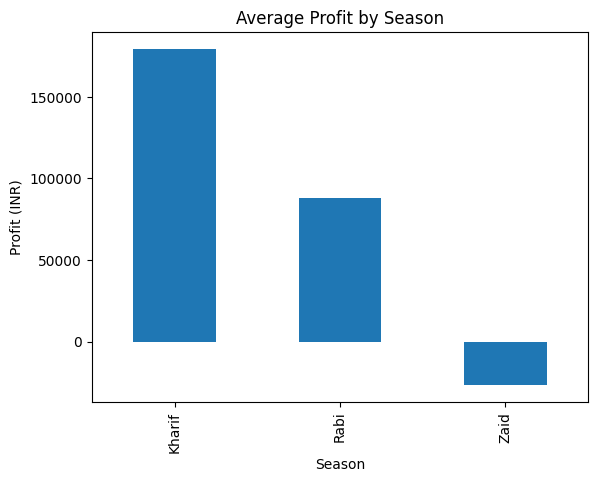

In [58]:
data.groupby('Season')['Profit_INR'].mean().plot(kind='bar')
plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')
plt.show()

### 8. Does crop yield change by season?

In [59]:
# Average yield for each crop in each season
data.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().unstack()

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731413,1.461615,1.177742
Cotton,1.372804,1.192915,0.951648
Groundnut,1.483646,1.221445,1.037778
Maize,2.966410,2.614913,2.297590
Pulses,1.036063,0.871887,0.652131
Rice,2.707621,2.333680,1.900490
Sugarcane,53.459120,43.940394,38.423922
Wheat,2.255430,2.058814,1.748588


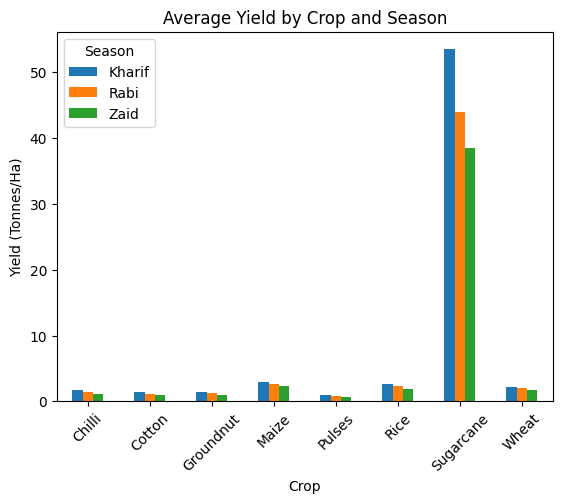

In [60]:
data.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().unstack().plot(kind='bar')
plt.title('Average Yield by Crop and Season')
plt.xlabel('Crop')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.show()

### 9. Does yield change by season across different states?

In [61]:
# Average yield by state and season
state_season = data.groupby(['State', 'Season'])['Yield_Tonnes_Ha'].mean().unstack()
state_season

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.693431,3.488069,4.480238
Gujarat,6.338416,5.517245,4.101970
Karnataka,6.523689,4.609655,6.623243
Madhya Pradesh,6.004133,3.800000,5.539194
Maharashtra,5.447014,5.501927,2.285352
Punjab,4.100633,8.609355,5.909610
Tamil Nadu,5.520534,4.555539,4.097746
Telangana,5.568798,4.831649,4.278333


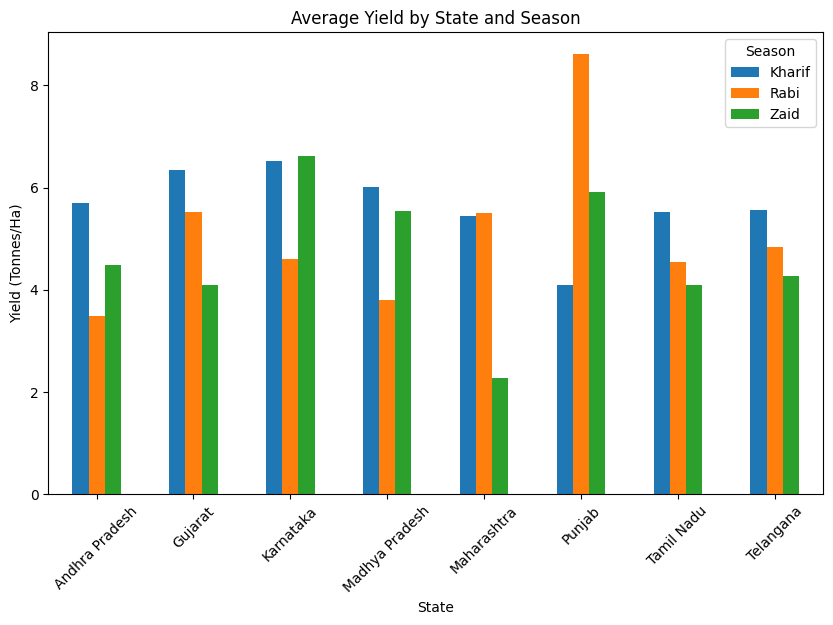

In [62]:
state_season.plot(kind='bar', figsize=(10, 6))
plt.title('Average Yield by State and Season')
plt.xlabel('State')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.show()

### 10. How does disease and pest risk vary by season?

In [63]:

data.groupby('Season')['Disease_Pest_Risk_pct'].mean()

,Disease_Pest_Risk_pct
Season,
Kharif,54.465858
Rabi,40.519788
Zaid,38.221392


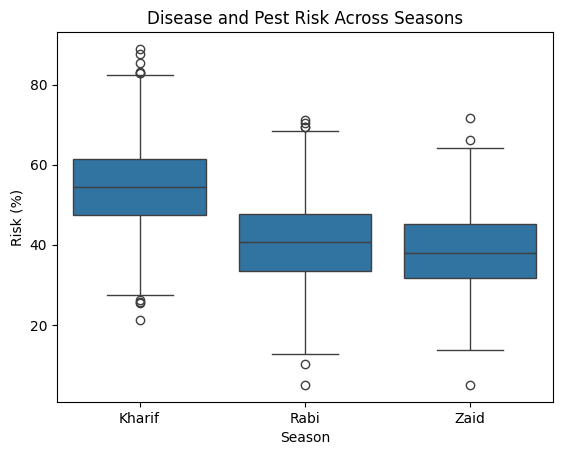

In [64]:
sns.boxplot(data=data, x='Season', y='Disease_Pest_Risk_pct')
plt.title('Disease and Pest Risk Across Seasons')
plt.xlabel('Season')
plt.ylabel('Risk (%)')
plt.show()

### 11. How does water efficiency differ between seasons?

In [65]:
data.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean()


,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.906584
Rabi,5.178462
Zaid,4.440922


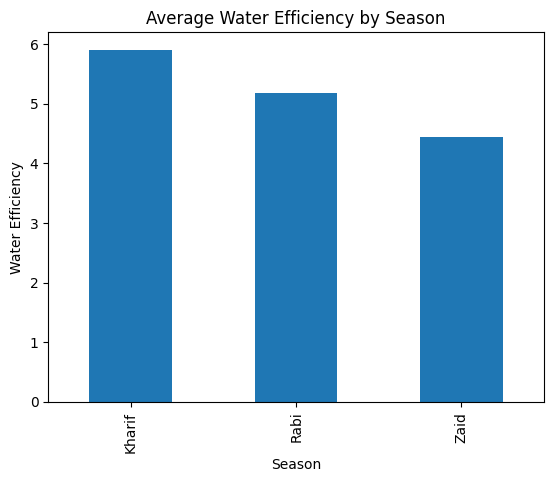

In [66]:
data.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean().plot(kind='bar')

plt.title('Average Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Water Efficiency')
plt.show()

## Conclusion

The results show differences between Kharif, Rabi and Zaid in terms of yield, production, resource usage, financial results and disease/pest risk. The seasonal comparisons help identify which areas perform better or worse and where planning may need more attention.

## Recommendations

- Plan resources according to the seasonal results.
- Check cost and expected profit before choosing a season for cultivation.
- Use water usage and water efficiency results when planning irrigation.
- Give more attention to seasons with higher disease or pest risk.
- Consider crop and state-level differences instead of using the same plan for every area.